In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/google-bert/bert-base-uncased

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/google-bert/bert-base-uncased)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("fill-mask", model="google-bert/bert-base-uncased")

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
model = AutoModelForMaskedLM.from_pretrained("google-bert/bert-base-uncased")

In [ ]:
from transformers import pipeline
unmasker = pipeline('fill-mask', model='bert-base-uncased')
# switch to other model
# unmasker = pipeline("fill-mask", model="anferico/bert-for-patents")
unmasker("Hello I'm a [MASK] model.")

In [ ]:
from ipywidgets import Widget
Widget.close_all()

In [ ]:
import pandas as pd

# clean data
data_set = pd.read_csv("data_science_project_data1.csv")

data_set["SeniorCitizen"] = data_set["SeniorCitizen"].map({1: "a senior citizen", 0: "not a senior citizen"})

data_set["Partner"] = data_set["Partner"].map({"Yes": "a partner", "No": "no partner"})

data_set["Dependents"] = data_set["Dependents"].map({"Yes": "dependents", "No": "no dependents"})

data_set["PhoneService"] = data_set["PhoneService"].map({"Yes": "have phone service", "No": "do not have phone service"})

data_set["MultipleLines"] = data_set["MultipleLines"].map(
    {"Yes": "I have multiple lines. ",
     "No": "I do not have multiple lines. ",
     "No phone service": ""}
)

data_set["InternetService"] = data_set["InternetService"].map(
    {"Fiber optic": "I have fiber optic internet service. ",
     "DSL": "I have DSL internet service. ",
     "No": ""}
)

data_set["OnlineSecurity"] = data_set["OnlineSecurity"].map(
    {
        "Yes": "I have online security. ",
        "No": "I do not have online security. ",
        "No internet service": ""
    }
)

data_set["OnlineBackup"] = data_set["OnlineBackup"].map(
    {
        "Yes": "I have online backup. ",
        "No": "I do not have online backup. ",
        "No internet service": ""}
)

data_set["DeviceProtection"] = data_set["DeviceProtection"].map(
    {
        "Yes": "I have device protection. ",
        "No": "I do not have device protection. ",
        "No internet service": ""}
)

data_set["TechSupport"] = data_set["TechSupport"].map(
    {
        "Yes": "I have tech support. ",
        "No": "I do not have tech support. ",
        "No internet service": ""}
)

data_set["StreamingTV"] = data_set["StreamingTV"].map(
    {
        "Yes": "I have streaming TV. ",
        "No": "I do not have streaming TV. ",
        "No internet service": ""}
)

data_set["StreamingMovies"] = data_set["StreamingMovies"].map(
    {
        "Yes": "I have streaming movies. ",
        "No": "I do not have streaming movies. ",
        "No internet service": ""}
)

data_set["Contract"] = data_set["Contract"].map(
    {"Month-to-month": "a month-to-month contract",
     "One year": "a one year contract",
     "Two year": "a two year contract"}
)

data_set["PaperlessBilling"] = data_set["PaperlessBilling"].map(
    {"Yes": "have paperless billing", "No": "do not have paperless billing"}
)

data_set.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data_science_project_data1.csv'

In [ ]:
# convert data_set into a list of string prompts
# Comment out to repliacate results for datasets 2 and 3
prompts = []
ds2_prompts = []
ds3_prompts = []

for index, row in data_set.iterrows():
  genderPrompt = f"I am a {row['gender']}. "
  seniorCitizenPrompt = f"I am a {row['SeniorCitizen']}. "
  partnerPrompt = f"I have {row['Partner']}. "
  dependentsPrompt = f"I have {row['Dependents']}. "
  tenurePrompt = f"I have been with the company for {row['tenure']} months. "
  phoneServicePrompt = f"I {row['PhoneService']}. "
  multipleLinesPrompt = f"{row['MultipleLines']}"
  internetServicePrompt = row["InternetService"]
  onlineSecurityPrompt = row["OnlineSecurity"]
  onlineBackupPrompt = row["OnlineBackup"]
  deviceProtectionPrompt = row["DeviceProtection"]
  techSupportPrompt = row["TechSupport"]
  streamingTVPrompt = row["StreamingTV"]
  streamingMoviesPrompt = row["StreamingMovies"]
  contractPrompt = f"My contract is a {row['Contract']}. "
  paperlessBillingPrompt = f"I {row['PaperlessBilling']}. "
  paymentPrompt = f"I pay my bills using a(n) {row['PaymentMethod']}. "
  monthlyChargesPrompt = f"My monthly charges are ${row['MonthlyCharges']}. "
  totalChargesPrompt = f"My total charges are ${row['TotalCharges']}. "

  prompt = genderPrompt + seniorCitizenPrompt + partnerPrompt + dependentsPrompt + tenurePrompt + phoneServicePrompt + multipleLinesPrompt + internetServicePrompt + onlineSecurityPrompt + onlineBackupPrompt + deviceProtectionPrompt + techSupportPrompt + streamingTVPrompt + streamingMoviesPrompt + contractPrompt + paperlessBillingPrompt + paymentPrompt + monthlyChargesPrompt + totalChargesPrompt
  ds2_prompt = seniorCitizenPrompt + partnerPrompt + dependentsPrompt + multipleLinesPrompt + internetServicePrompt + onlineBackupPrompt + deviceProtectionPrompt + techSupportPrompt + contractPrompt + monthlyChargesPrompt + totalChargesPrompt
  ds3_prompt = dependentsPrompt + internetServicePrompt + techSupportPrompt + contractPrompt + totalChargesPrompt

  funnel_clause = "I am undecided as to whether I should keep or cancel my internet service. However I have deicded and knowing all of what I have said before, I decided to [MASK] my internet service."

  prompt += funnel_clause
  ds2_prompt += funnel_clause
  ds3_prompt += funnel_clause

  prompts.append(prompt)
  ds2_prompts.append(ds2_prompt)
  ds3_prompts.append(ds3_prompt)


unmasker(prompts[15])


[{'score': 0.47473740577697754,
  'token': 2227,
  'token_str': 'keep',
  'sequence': 'i am a female. i am a not a senior citizen. i have a partner. i have dependents. i have been with the company for 69 months. i have phone service. i have multiple lines. i have fiber optic internet service. i have online security. i have online backup. i have device protection. i have tech support. i have streaming tv. i have streaming movies. my contract is a a two year contract. i do not have paperless billing. i pay my bills using a ( n ) credit card ( automatic ). my monthly charges are $ 113. 25. my total charges are $ 7895. 15. i am undecided as to whether i should keep or cancel my internet service. however i have deicded and knowing all of what i have said before, i decided to keep my internet service.'},
 {'score': 0.19013425707817078,
  'token': 17207,
  'token_str': 'cancel',
  'sequence': 'i am a female. i am a not a senior citizen. i have a partner. i have dependents. i have been with th

In [ ]:
# Sort into two groups. Keep and let go of service

not_churned =     ["keep"]
churned =         ["cancel", "abandon", "terminate", "end"]

predicted_churned = []
predicted_not_churned = []
not_classified = []

i = -1
for prompt in ds3_prompts:
  i += 1
  result = unmasker(prompt)
  for entry in result:
    if entry["token_str"] in churned:
      predicted_churned.append({"index": i, "word": entry["token_str"]})
      break
    elif entry["token_str"] in not_churned:
      predicted_not_churned.append({"index": i, "word": entry["token_str"]})
      break

#predicted_churned

# Evaluation Metrics

TP: True Positive

TN: True Negative

FP: False Positive

FN: False Negative

In [ ]:
# Calculate base accuracy
total_churned = 0
for index, row in data_set.iterrows():
  if row["Churn"] == "Yes":
    total_churned += 1

base_accuracy = total_churned / len(data_set)
print(f"Base Accuracy: {base_accuracy}")

Base Accuracy: 0.2653698707936959


In [ ]:
true_positive = 0
true_negative = 0
false_positive = 0
false_negative = 0

for entry in predicted_churned:
  index = entry["index"]

  # True Positive
  if data_set.iloc[index]["Churn"] == "Yes":
    true_positive += 1

  # False Positive
  else:
    false_positive += 1

for entry in predicted_not_churned:
  index = entry["index"]

  # True Negative
  if data_set.iloc[index]["Churn"] == "No":
    true_negative += 1

  # False Negative
  else:
    false_negative += 1

print(f"True Positive: {true_positive}")
print(f"True Negative: {true_negative}")
print(f"False Positive: {false_positive}")
print(f"False Negative: {false_negative}")

print("")

print(f"Accuracy: {(true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)}")
print(f"Precision: {true_positive / (true_positive + false_positive)}")
print(f"Recall: {true_positive / (true_positive + false_negative)}")




True Positive: 0
True Negative: 5174
False Positive: 0
False Negative: 1869

Accuracy: 0.7346301292063041


ZeroDivisionError: division by zero

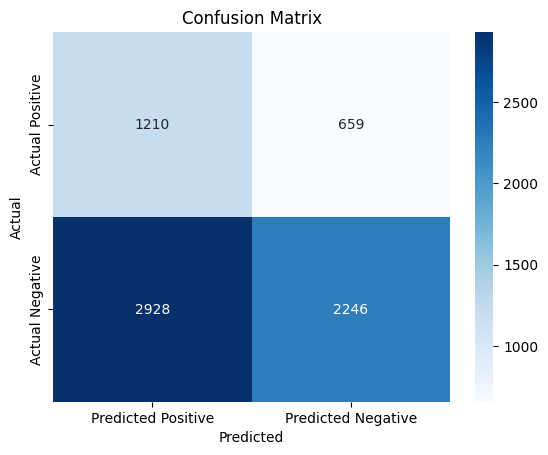

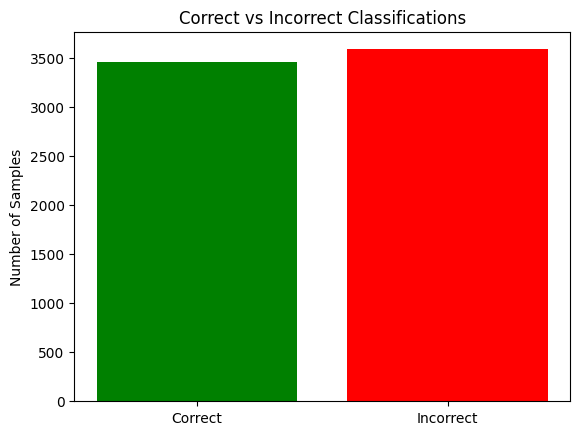

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visuals
# Model #1, Dataset #1
tp = 1210
tn = 2246
fp = 2928
fn = 659

# Create confusion matrix as a DataFrame
cm = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=['Actual Positive', 'Actual Negative'],
    columns=['Predicted Positive', 'Predicted Negative']
)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Create bar chart for correct vs incorrect
correct = tp + tn
incorrect = fp + fn

plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title('Correct vs Incorrect Classifications')
plt.ylabel('Number of Samples')
plt.show()

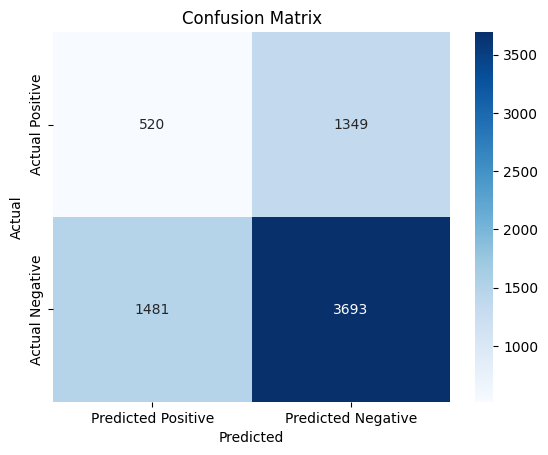

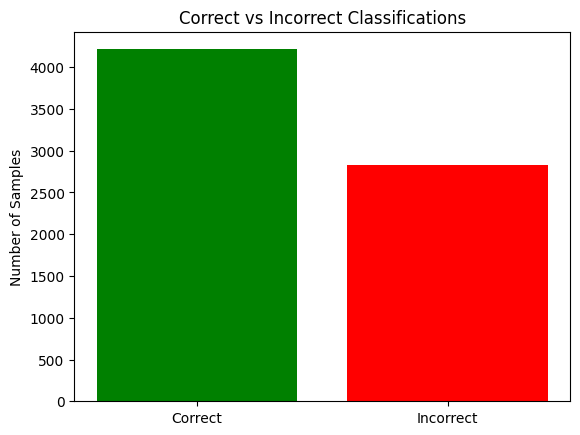

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visuals
# Model #1, Dataset #2
tp = 520
tn = 3693
fp = 1481
fn = 1349

# Create confusion matrix as a DataFrame
cm = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=['Actual Positive', 'Actual Negative'],
    columns=['Predicted Positive', 'Predicted Negative']
)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Create bar chart for correct vs incorrect
correct = tp + tn
incorrect = fp + fn

plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title('Correct vs Incorrect Classifications')
plt.ylabel('Number of Samples')
plt.show()

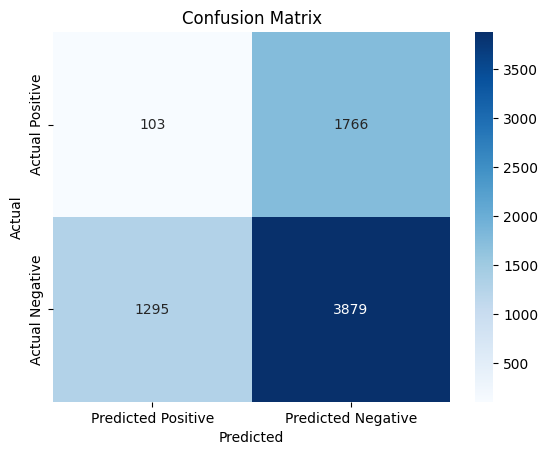

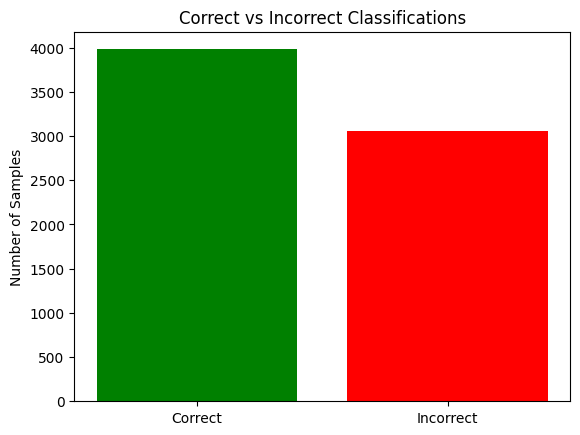

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visuals
# Model #1, Dataset #3
tp = 103
tn = 3879
fp = 1295
fn = 1766

# Create confusion matrix as a DataFrame
cm = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=['Actual Positive', 'Actual Negative'],
    columns=['Predicted Positive', 'Predicted Negative']
)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Create bar chart for correct vs incorrect
correct = tp + tn
incorrect = fp + fn

plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title('Correct vs Incorrect Classifications')
plt.ylabel('Number of Samples')
plt.show()

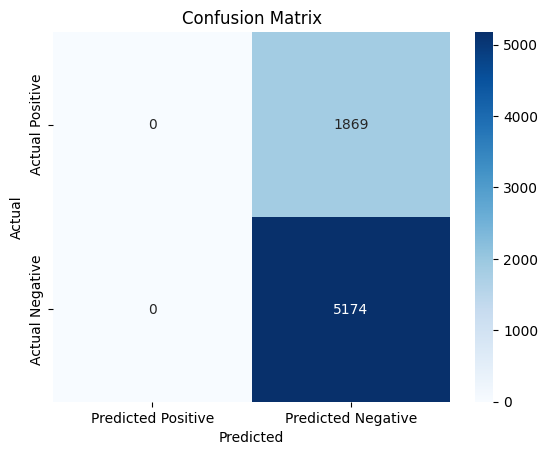

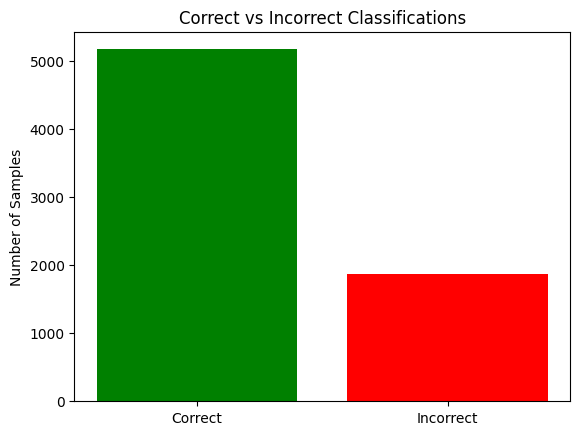

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visuals
# Model #2, Dataset #1-3
tp = 0
tn = 5174
fp = 0
fn = 1869

# Create confusion matrix as a DataFrame
cm = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=['Actual Positive', 'Actual Negative'],
    columns=['Predicted Positive', 'Predicted Negative']
)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Create bar chart for correct vs incorrect
correct = tp + tn
incorrect = fp + fn

plt.bar(['Correct', 'Incorrect'], [correct, incorrect], color=['green', 'red'])
plt.title('Correct vs Incorrect Classifications')
plt.ylabel('Number of Samples')
plt.show()